In [ ]:
# STalign path configuration (auto-generated)
from pathlib import Path
import os
import re
import pandas as pd
import numpy as np

from PIL import Image
def detect_workdir() -> str:
    home = os.path.expanduser("~")
    if home in ["/Users/youyun", "/Users/youyunzheng"]:
        return home + "/Documents/HMS/PhD/beroukhimlab/dfci_mount/"
    if home == "/home/yz762":
        return "/mnt/storage/dept/medonc/beroukhim/"
    if home == "/PHShome/yz762":
        return "/data/beroukhim1/"
    return "/data/beroukhim1/"


WORKDIR = Path(detect_workdir())
XENIUM_ANNOT_ROOT = WORKDIR / "youyun/plgg/data/Xenium_annotations"
PROSEG_ROOT = WORKDIR / "youyun/plgg/data/segmentation/proseg_run_121024"
METADATA_XLSX = WORKDIR / "youyun/plgg/data/metadata/Xenium_PS.xlsx"
OUTPUT_ROOT = WORKDIR / "youyun/plgg/data/Xenium_annotations/pathology_annotations_030226"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

SAMPLE_ID = "CL87352"
IMAGE_GROUP = "LGG2"

GEOJSON_PATH = XENIUM_ANNOT_ROOT / "geojsons" / f"230918_Xenium_CytAssist_{IMAGE_GROUP}.geojson"
if not GEOJSON_PATH.exists():
    raise FileNotFoundError(
        f"Missing canonical GeoJSON for {SAMPLE_ID}: {GEOJSON_PATH}. "
        "GeoJSON files are assumed to be pre-staged under geojsons/."
    )

IMAGE_JPG_ROOT = XENIUM_ANNOT_ROOT / "images"
IMAGE_FILE = IMAGE_JPG_ROOT / f"230918_Xenium_CytAssist_{IMAGE_GROUP}.jpg"
if not IMAGE_FILE.exists():
    raise FileNotFoundError(
        f"Missing JPG image for {SAMPLE_ID}: {IMAGE_FILE}. "
        "JPG images are assumed to be pre-staged under images/."
    )

def read_jpg(path: Path) -> np.ndarray:
    img = np.asarray(Image.open(path).convert("RGB"))
    return img

def resolve_cells_csv(sample_id: str) -> Path:
    metadata = pd.read_excel(METADATA_XLSX)
    numeric_id = re.sub(r"^[A-Za-z]+", "", sample_id)
    matches = metadata.loc[metadata["id"].astype(str) == numeric_id, "file"]
    if matches.empty:
        raise ValueError(f"Could not find sample {sample_id} in metadata: {METADATA_XLSX}")

    file_name = matches.iloc[0]
    cells_csv = PROSEG_ROOT / file_name / f"{file_name}_proseg" / "outs" / "cells.csv.gz"
    if not cells_csv.exists():
        raise FileNotFoundError(f"cells.csv.gz missing for {sample_id}: {cells_csv}")
    return cells_csv


CELL_CSV_PATH = resolve_cells_csv(SAMPLE_ID)
OUTPUT_FILE = OUTPUT_ROOT / f"proseg_pathology_{SAMPLE_ID}_proseg_meta.csv"


In [1]:
import matplotlib.pyplot as plt
import geopandas as gpd
import geoplot
import geoplot.crs as gcrs
import pandas as pd
import numpy as np
from STalign import STalign
import seaborn as sns
from shapely.geometry import shape, GeometryCollection, Point
import scipy

## Methods

In [2]:
# Function to convert a string to a tuple
def string_to_tuple(text):
  return tuple(text.split(','))
    
def rgb2hex(r,g,b):
    hex = "#{:02x}{:02x}{:02x}".format(r,g,b)
    return hex

In [3]:
def geojson_contains_xy(geojson, xy):
    if s.contains(xy).any():
        return s[s.contains(Point(xy))]['color'].values[0]
    else:
        return "unannotated"

# H&E and Geojson

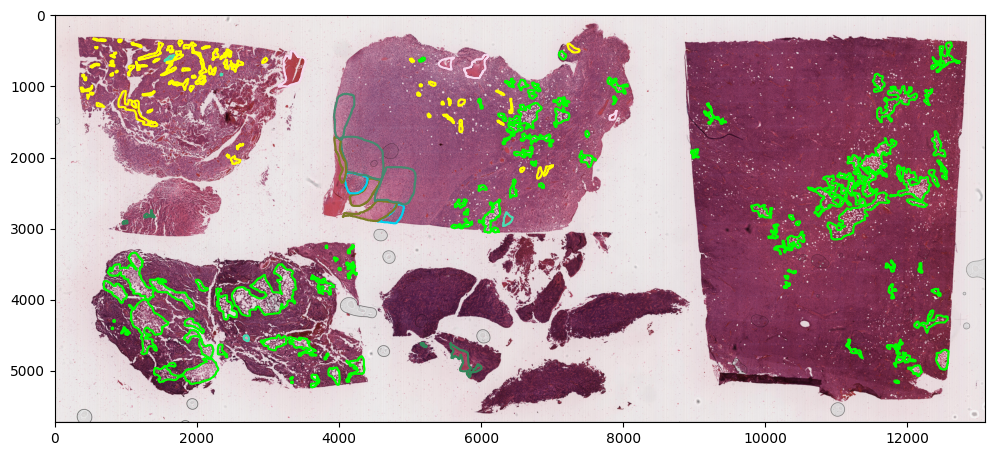

In [7]:
# Read in geojson and add color based on annotation

# Convert GeoJSON to a GeoDataFrame
df_geojson = gpd.read_file(GEOJSON_PATH)
s = gpd.GeoDataFrame(df_geojson)
classification_str = s['classification'].astype(str)
s['name'] = classification_str.str.split("'", expand = True)[3]
s['rgb'] = classification_str.str.split('[', expand = True)[1].str.split(']', expand = True)[0].apply(string_to_tuple)
s['color'] = s['rgb'].apply(lambda x: 
                              rgb2hex(int(x[0]),int(x[1]),int(x[2]))
                             )
s.geometry = s.geometry.scale(xfact=1/7, yfact=1/7, origin=(0,0))

# Read in H&E Image
image_file = str(IMAGE_FILE)
V = read_jpg(IMAGE_FILE)

### Plot
# H&E
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(V)
#Geojson
s.boundary.plot(ax=ax,color=s['color'],aspect=1)
# STAlign adjusted Xenium
plt.show()


# ST Align

0.0
1.0


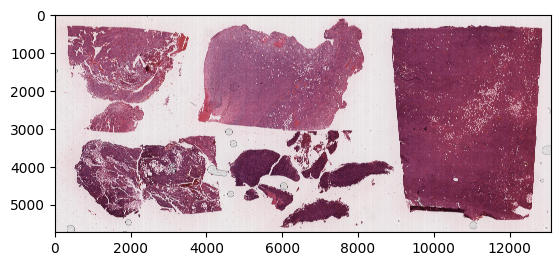

In [8]:
V = read_jpg(IMAGE_FILE)
Inorm = STalign.normalize(V)

print(Inorm.min())
print(Inorm.max())

fig,ax = plt.subplots()
ax.imshow(Inorm)

In [9]:
I = Inorm.transpose(2,0,1)
print(I.shape)

YI = np.array(range(I.shape[1]))*1. # needs to be longs not doubles for STalign.transform later so multiply by 1.
XI = np.array(range(I.shape[2]))*1. # needs to be longs not doubles for STalign.transform later so multiply by 1.
extentI = STalign.extent_from_x((YI,XI))

(3, 5727, 13090)


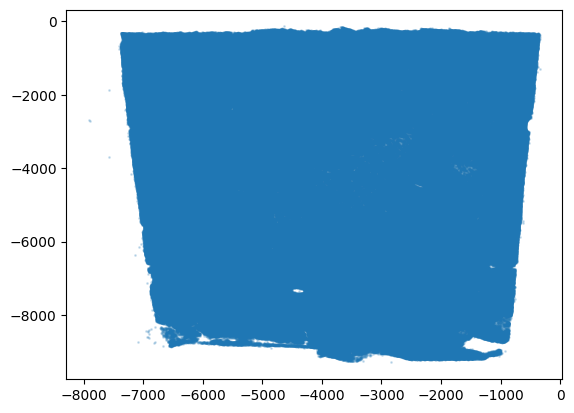

In [10]:
cell_csv = pd.read_csv(CELL_CSV_PATH)
# get cell centroid coordinates
xM = -np.array(cell_csv['y_centroid'])
yM = -np.array(cell_csv['x_centroid'])

# plot
fig,ax = plt.subplots()
ax.scatter(xM,yM,s=1,alpha=0.2)

0 of 705600
10000 of 705600
20000 of 705600
30000 of 705600
40000 of 705600
50000 of 705600
60000 of 705600
70000 of 705600
80000 of 705600
90000 of 705600
100000 of 705600
110000 of 705600
120000 of 705600
130000 of 705600
140000 of 705600
150000 of 705600
160000 of 705600
170000 of 705600
180000 of 705600
190000 of 705600
200000 of 705600
210000 of 705600
220000 of 705600
230000 of 705600
240000 of 705600
250000 of 705600
260000 of 705600
270000 of 705600
280000 of 705600
290000 of 705600
300000 of 705600
310000 of 705600
320000 of 705600
330000 of 705600
340000 of 705600
350000 of 705600
360000 of 705600
370000 of 705600
380000 of 705600
390000 of 705600
400000 of 705600
410000 of 705600
420000 of 705600
430000 of 705600
440000 of 705600
450000 of 705600
460000 of 705600
470000 of 705600
480000 of 705600
490000 of 705600
500000 of 705600
510000 of 705600
520000 of 705600
530000 of 705600
540000 of 705600
550000 of 705600
560000 of 705600
570000 of 705600
580000 of 705600
590000 of 7

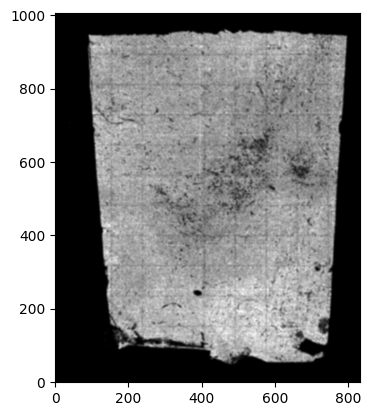

In [11]:
# rasterize at 30um resolution (assuming positions are in um units) and plot
XJ,YJ,M,fig = STalign.rasterize(xM, yM, dx=10)

ax = fig.axes[0]
ax.invert_yaxis()

In [12]:
print(M.shape)
J = np.vstack((M, M, M)) # make into 3xNxM
print(J.min())
print(J.max())

# normalize
J = STalign.normalize(J)
print(J.min())
print(J.max())

# double check size of things
print(I.shape)
print(M.shape)
print(J.shape)

(1, 1008, 833)
0.0
2.0733506040336356
0.0
1.0
(3, 5727, 13090)
(1, 1008, 833)
(3, 1008, 833)


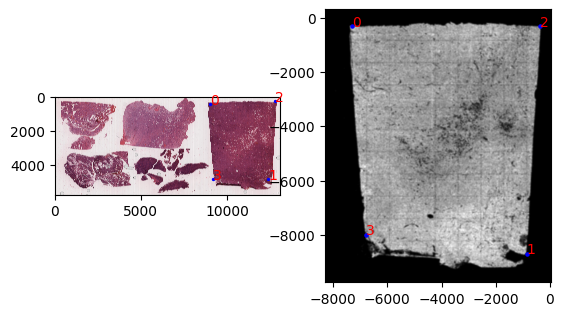

In [26]:
# manually make corresponding points
pointsI = np.array([[450.,9000.],[4800., 12400.],
                    [275., 12800.],[4800.,9200.]])
pointsJ = np.array([[-300.,-7300.],[-8700., -850.],
                    [-300., -350.],[-8000., -6800.]])

# plot
extentJ = STalign.extent_from_x((YJ,XJ))

fig,ax = plt.subplots(1,2)
ax[0].imshow((I.transpose(1,2,0).squeeze()), extent=extentI)
ax[1].imshow((J.transpose(1,2,0).squeeze()), extent=extentJ)

ax[0].scatter(pointsI[:,1],pointsI[:,0], c='blue',s=2)
ax[1].scatter(pointsJ[:,1],pointsJ[:,0], c='blue',s=5)
for i in range(pointsI.shape[0]):
    ax[0].text(pointsI[i,1],pointsI[i,0],f'{i}', c='red')
    ax[1].text(pointsJ[i,1],pointsJ[i,0],f'{i}', c='red')

# invert only rasterized image
ax[1].invert_yaxis()

In [27]:
# compute initial affine transformation from points
L,T = STalign.L_T_from_points(pointsI,pointsJ)

[[-1.81818113 -0.13978649]
 [ 0.04172555  1.8427036 ]]
[  1884.86343062 -23926.03813283]
(2, 2)
(2,)
(2, 705600)


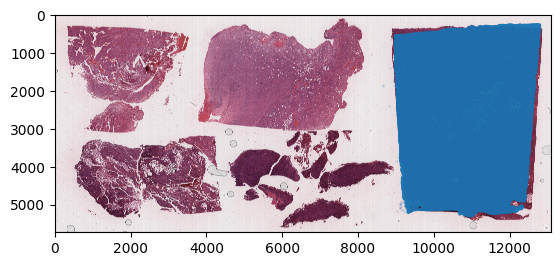

In [28]:
print(L)
print(T)
print(L.shape)
print(T.shape)

# note points are as y,x
affine = np.dot(np.linalg.inv(L), [yM - T[0], xM - T[1]])
print(affine.shape)
xMaffine = affine[0,:]
yMaffine = affine[1,:]

# plot
fig,ax = plt.subplots()
ax.scatter(yMaffine,xMaffine,s=1,alpha=0.1)
ax.imshow((I).transpose(1,2,0))

In [29]:
import torch
# set device for building tensors
if torch.cuda.is_available():
    torch.set_default_device('cuda:0')
else:
    torch.set_default_device('cpu')

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3484.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/STalign/STalign.py:1301: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axE[2].set_yscale('log')


CPU times: user 25min 35s, sys: 11min 24s, total: 36min 59s
Wall time: 17min 12s


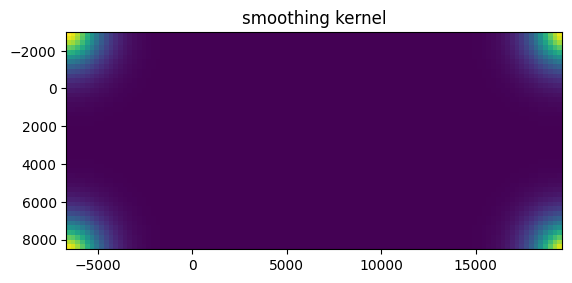

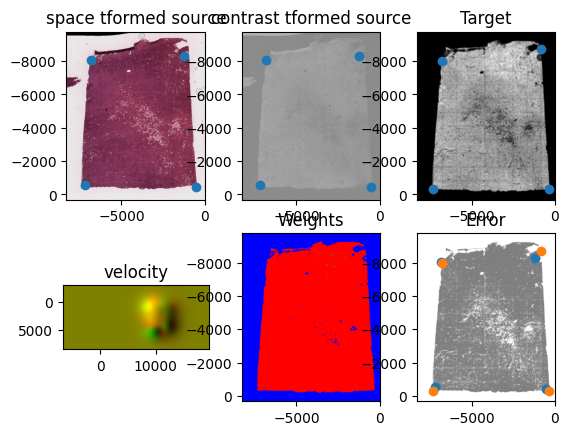

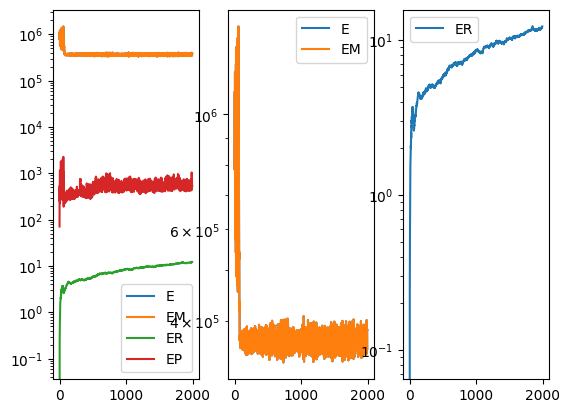

In [30]:
%%time

# run LDDMM
# specify device (default device for STalign.LDDMM is cpu)
if torch.cuda.is_available():
    device = 'cuda:0'
else:
    device = 'cpu'

# keep all other parameters default
params = {'L':L,'T':T,
          'niter':2000,
          'pointsI':pointsI,
          'pointsJ':pointsJ,
          'device':device,
          'sigmaM':0.15,
          'sigmaB':0.10,
          'sigmaA':0.11,
          'epV': 10,
          'muB': torch.tensor([0,0,0]), # black is background in target
          'muA': torch.tensor([1,1,1]) # use white as artifact
          }

out = STalign.LDDMM([YI,XI],I,[YJ,XJ],J,**params)

In [31]:
# get necessary output variables
A = out['A']
v = out['v']
xv = out['xv']

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/utils/_device.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


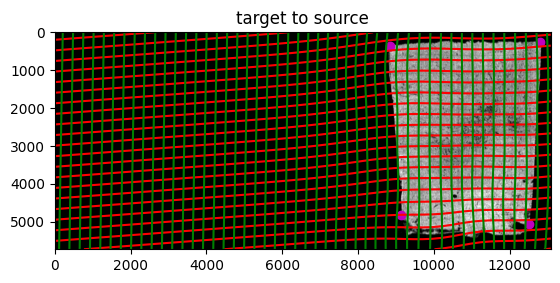

In [32]:
# now transform the points
phi = STalign.build_transform(xv,v,A,XJ=[YI,XI],direction='f')
phiiJ = STalign.transform_image_target_to_source(xv,v,A,[YJ,XJ],J,[YI,XI])
phiipointsJ = STalign.transform_points_target_to_source(xv,v,A,pointsJ)

#switch tensor from cuda to cpu for plotting with numpy
if phi.is_cuda:
    phi = phi.cpu()
if phiiJ.is_cuda:
    phiiJ = phiiJ.cpu()
if phiipointsJ.is_cuda:
    phiipointsJ = phiipointsJ.cpu()

# plot
fig,ax = plt.subplots()

levels = np.arange(-50000,50000,500)

ax.contour(XI,YI,phi[...,0],colors='r',linestyles='-',levels=levels)
ax.contour(XI,YI,phi[...,1],colors='g',linestyles='-',levels=levels)
ax.set_aspect('equal')
ax.set_title('target to source')

ax.imshow(phiiJ.permute(1,2,0),extent=extentI)
ax.scatter(phiipointsJ[:,1].detach(),phiipointsJ[:,0].detach(),c="m")

In [33]:
# Now apply to points
tpointsJ = STalign.transform_points_target_to_source(xv,v,A,np.stack([yM, xM], -1))

#switch tensor from cuda to cpu for plotting with numpy
if tpointsJ.is_cuda:
    tpointsJ = tpointsJ.cpu()

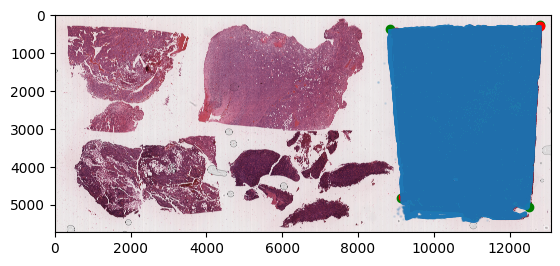

In [ ]:
###### plot
fig,ax = plt.subplots()
ax.imshow((I).transpose(1,2,0),extent=extentI)
ax.scatter(phiipointsJ[:,1].detach(),phiipointsJ[:,0].detach(),c="g")
ax.scatter(pointsI[:,1],pointsI[:,0], c='r')
ax.scatter(tpointsJ[:,1].detach(),tpointsJ[:,0].detach(),s=1,alpha=0.1)

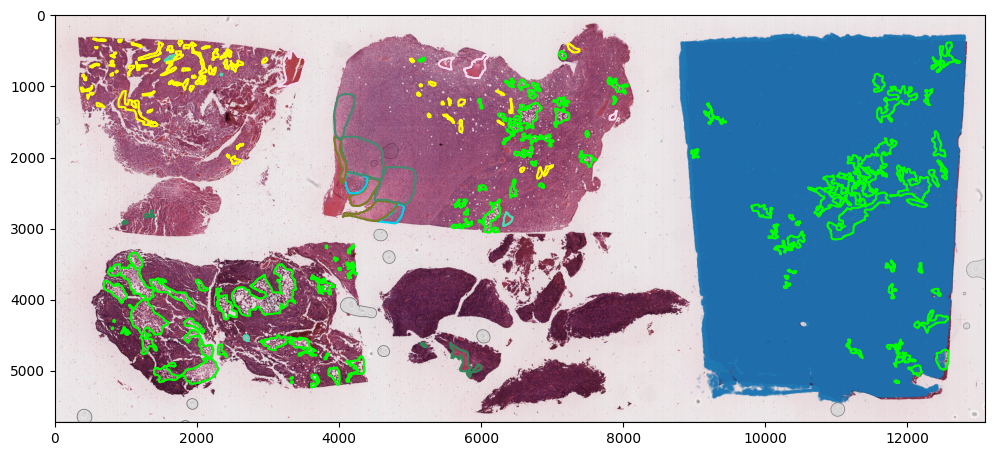

In [37]:
# Read in geojson and add color based on annotation

df_geojson = gpd.read_file(GEOJSON_PATH)
s = gpd.GeoDataFrame(df_geojson)
classification_str = s['classification'].astype(str)
s['name'] = classification_str.str.split("'", expand = True)[3]
s['color'] = classification_str.str.split('[', expand = True)[1].str.split(']', expand = True)[0].apply(string_to_tuple)
s['color'] = s['color'].apply(lambda x: 
                              rgb2hex(int(x[0]),int(x[1]),int(x[2]))
                             )
# scale
s.geometry = s.geometry.scale(xfact=1/7, yfact=1/7, origin=(0,0))

# Read in H&E Image
image_file = str(IMAGE_FILE)
V = read_jpg(IMAGE_FILE)

### Plot
# H&E
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(V)
#Geojson
s.boundary.plot(ax=ax,color=s['color'],aspect=1)
# STAlign adjusted Xenium
ax.scatter(tpointsJ[:,1].detach(),tpointsJ[:,0].detach(),s=1,alpha=0.1)
plt.show()

# Annotation Plotting

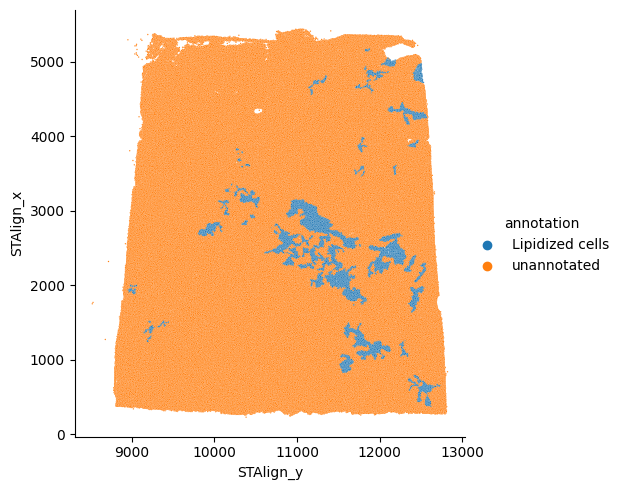

In [41]:
results = np.hstack((cell_csv, tpointsJ.numpy()))
results = pd.DataFrame(results)

names = list(cell_csv.columns)
names.append("STAlign_x")
names.append("STAlign_y")
names

results.columns = names
results['adjust_xy'] = list(zip(results['STAlign_y'], results['STAlign_x']))
results['annotation'] = results['adjust_xy'].apply(lambda x: geojson_contains_xy(s,Point(x)))
results['annotation'] =results['annotation'].astype('category')

recode_map = {'#00ff00': 'Lipidized cells','#33865a':'Neuropil zone',
'#ffff00':'Perivascular pseudorosettes',
'#f6daef':'blood',
'#48ddb2':'Amorphic material',
'#7c7b26':'Cerebellum, molecular layer',
'#468a70':'Infiltration zone',
'#00d2ef':'Cerebellum, granule cell layer'}
results['annotation'] = results['annotation'].replace(recode_map)

sns.relplot(data=results, x='STAlign_y', y='STAlign_x',s=1,hue='annotation')
plt.show()

In [42]:
results.to_csv(OUTPUT_FILE, index=False)